## General Strategy Comparison

In [122]:
import pandas as pd

# Load the uploaded CSV file
file_path = "/Users/wanghao/Desktop/ssp_abm/data/ssp_results.csv"
df = pd.read_csv(file_path)

# Show the first few rows to understand the structure
df.head()

,Strategy,Seed,Step,Total_Investigations,Detection_Precision,Avg_Detection_Delay,Avg_Offences_per_Detected,Avg_Risk,Avg_Escapes,Police_Efficiency,...,Detected_Criminals,Avg_Cost_per_Detection,False_Positives,Active_Serious_Remaining,Total_Serious_Offences,Total_Minor_Offences,Total_Offences,Detections_per_10_Investigations,SSP_Resolved_Serious,Investigation_Success_Rate
0,SSP_Low,0,0,15,0.0,0.0,0.0,0.487856,0.040404,0.00,...,1,0.0,4,7,0,0,0,0.000000,0,0.733333
1,SSP_Low,0,1,29,0.2,3.0,1.6,0.473741,0.063158,0.05,...,5,7.0,7,6,0,1,1,0.344828,0,0.689655
2,SSP_Low,0,2,29,0.2,3.0,1.6,0.460437,0.063158,0.05,...,5,7.0,7,6,0,2,2,0.344828,0,0.689655
3,SSP_Low,0,3,29,0.2,3.0,1.6,0.446301,0.063158,0.05,...,5,7.0,7,6,0,3,3,0.344828,0,0.689655
4,SSP_Low,0,4,29,0.2,3.0,1.6,0.433499,0.063158,0.05,...,5,7.0,7,6,0,4,4,0.344828,0,0.689655


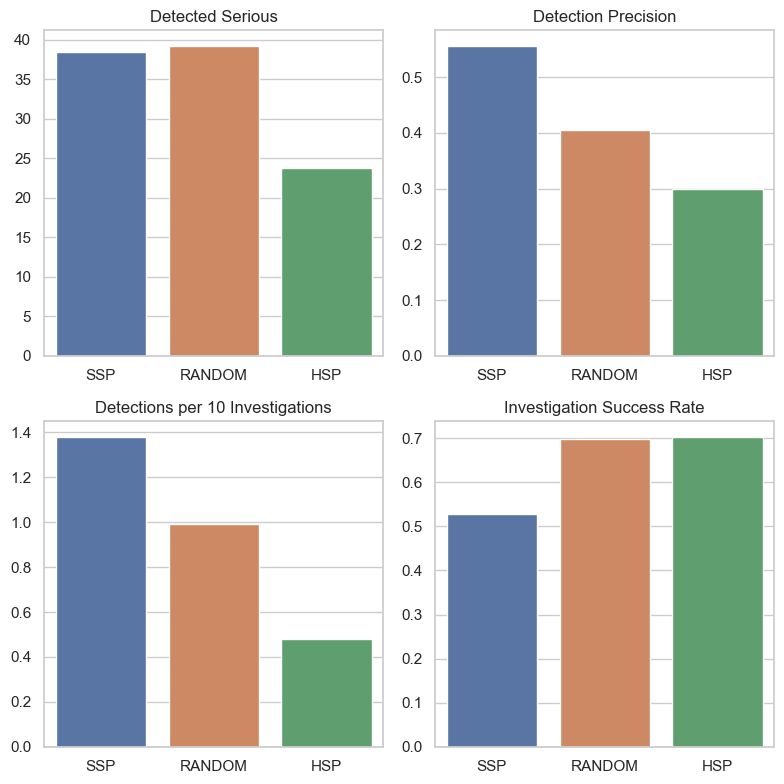

In [161]:
# Filter for the final step only
df_step_499 = df[df["Step"] == 499]

# Compute mean over 50 seeds for each strategy at step 499
summary_step_499 = df_step_499.groupby("Strategy").agg({
    "Detected_Serious": "mean",
    "Detection_Precision": "mean",
    "Detections_per_10_Investigations": "mean",
    "Investigation_Success_Rate": "mean",
}).reset_index()

# Set categorical order for consistent plotting
summary_step_499["Strategy"] = pd.Categorical(
    summary_step_499["Strategy"],
    categories=["SSP", "RANDOM", "HSP"],
    ordered=True
)

import matplotlib.pyplot as plt
import seaborn as sns

# Set style and palette
sns.set_palette("deep")

# Plot 4 key indicators
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

metrics = [
    "Detected_Serious",
    "Detection_Precision",
    "Detections_per_10_Investigations",
    "Investigation_Success_Rate",
]

for ax, metric in zip(axes, metrics):
    sns.barplot(data=summary_step_499, x="Strategy", y=metric, ax=ax, hue="Strategy", dodge=False)
    ax.set_title(metric.replace("_", " "), fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend_.remove()

plt.tight_layout()
plt.show()


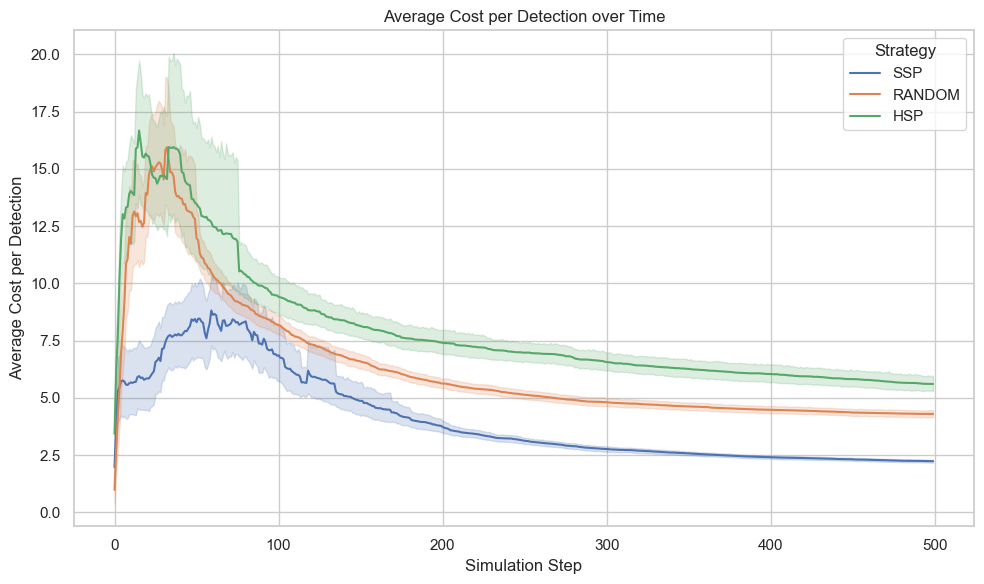

In [124]:
# Plot average cost per detection over time for each strategy
df["Strategy"] = pd.Categorical(
    df["Strategy"],
    categories=["SSP", "RANDOM", "HSP"],
    ordered=True
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Step", y="Avg_Cost_per_Detection", hue="Strategy")
plt.title("Average Cost per Detection over Time")
plt.xlabel("Simulation Step")
plt.ylabel("Average Cost per Detection")
plt.tight_layout()
plt.show()

In [126]:

# Ensure Strategy is a categorical variable with SSP as the reference level
df["Strategy"] = pd.Categorical(df["Strategy"], categories=["SSP", "RANDOM", "HSP"], ordered=True)

# Run the regression model with SSP as the baseline
model = smf.ols("Avg_Cost_per_Detection ~ C(Strategy) + Step + C(Strategy):Step", data=df).fit()

# Show the regression coefficient table
model.summary2().tables[1]


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,7.043093,0.045679,154.186712,0.000000e+00,6.953562,7.132623
C(Strategy)[T.RANDOM],3.162929,0.064600,48.961874,0.000000e+00,3.036314,3.289545
C(Strategy)[T.HSP],4.897991,0.064600,75.820489,0.000000e+00,4.771376,5.024607
Step,-0.011952,0.000158,-75.418455,0.000000e+00,-0.012263,-0.011641
C(Strategy)[T.RANDOM]:Step,-0.003400,0.000224,-15.171832,6.491218e-52,-0.003840,-0.002961
C(Strategy)[T.HSP]:Step,-0.003821,0.000224,-17.050922,4.566001e-65,-0.004261,-0.003382


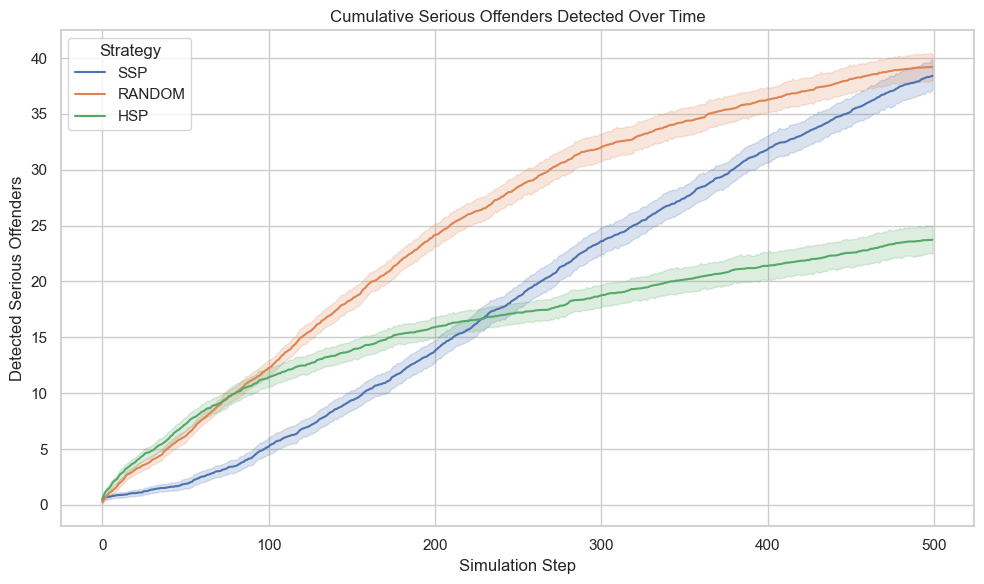

In [127]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Step", y="Detected_Serious", hue="Strategy")
plt.title("Cumulative Serious Offenders Detected Over Time")
plt.xlabel("Simulation Step")
plt.ylabel("Detected Serious Offenders")
plt.tight_layout()
plt.show()

In [128]:
# Ensure Strategy is a categorical variable with SSP as the reference level
df["Strategy"] = pd.Categorical(df["Strategy"], categories=["SSP", "RANDOM", "HSP"], ordered=True)

# Run the regression model with SSP as the baseline
model = smf.ols("Detected_Serious ~ C(Strategy) + Step + C(Strategy):Step", data=df).fit()

# Show the regression coefficient table
model.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,-2.284394,0.051355,-44.482031,0.000000e+00,-2.385051,-2.183738
C(Strategy)[T.RANDOM],7.628120,0.072628,105.030651,0.000000e+00,7.485770,7.770469
C(Strategy)[T.HSP],8.891236,0.072628,122.422344,0.000000e+00,8.748886,9.033586
Step,0.083778,0.000178,470.221246,0.000000e+00,0.083429,0.084127
C(Strategy)[T.RANDOM]:Step,-0.004791,0.000252,-19.014461,2.003638e-80,-0.005285,-0.004297
C(Strategy)[T.HSP]:Step,-0.045623,0.000252,-181.067478,0.000000e+00,-0.046117,-0.045129


## ANOVA

In [140]:
# Load the newly uploaded police efficiency CSV for updated analysis
df_eff = pd.read_csv("/Users/wanghao/Desktop/ssp_abm/data/ssp_results.csv")

# 重命名 Police_Efficiency 为 Police_Efficiency_Serious
df_eff.rename(columns={"Police_Efficiency": "Police_Efficiency_Serious"}, inplace=True)

# 计算 Police_Efficiency_Minor = (Detected_Criminals - Detected_Serious) / Police Number (20)
df_eff["Police_Efficiency_Minor"] = (df_eff["Detected_Criminals"] - df_eff["Detected_Serious"]) / 20

# Show all column names to correctly identify available variables
df_eff.columns.tolist()

['Strategy',
 'Seed',
 'Step',
 'Total_Investigations',
 'Detection_Precision',
 'Avg_Detection_Delay',
 'Avg_Offences_per_Detected',
 'Avg_Risk',
 'Avg_Escapes',
 'Police_Efficiency_Serious',
 'Active_Criminals',
 'Detected_Serious',
 'Detected_Criminals',
 'Avg_Cost_per_Detection',
 'False_Positives',
 'Active_Serious_Remaining',
 'Total_Serious_Offences',
 'Total_Minor_Offences',
 'Total_Offences',
 'Detections_per_10_Investigations',
 'SSP_Resolved_Serious',
 'Investigation_Success_Rate',
 'Police_Efficiency_Minor']

In [142]:
from scipy.stats import f_oneway

# 从原始列表中剔除高共线性的两个变量
metrics_filtered = [
    "Avg_Cost_per_Detection",
    "Detection_Precision",
    "Avg_Risk",
    "Avg_Escapes",
    "Police_Efficiency_Serious",
    "Police_Efficiency_Minor",
    "Total_Investigations",
    "Detected_Serious",
    "Active_Criminals",
    'Avg_Detection_Delay',
    'Avg_Offences_per_Detected'
]

# 再次执行 ANOVA 分析
anova_filtered_results = {}
for metric in metrics_filtered:
    groups = [df_eff[df_eff["Strategy"] == s][metric] for s in ["SSP", "HSP", "RANDOM"]]
    stat, p = f_oneway(*groups)
    anova_filtered_results[metric] = {"F-statistic": stat, "p-value": p}

# 输出成表格
pd.DataFrame(anova_filtered_results).T


,F-statistic,p-value
Avg_Cost_per_Detection,5633.249559,0.0
Detection_Precision,8778.267425,0.0
Avg_Risk,7493.352558,0.0
Avg_Escapes,3163.624398,0.0
Police_Efficiency_Serious,4465.757885,0.0
Police_Efficiency_Minor,61514.196542,0.0
Total_Investigations,45162.829479,0.0
Detected_Serious,4465.757885,0.0
Active_Criminals,21273.760438,0.0
Avg_Detection_Delay,12511.681689,0.0


One-way ANOVA revealed statistically significant differences across patrol strategies in all core performance indicators, including Avg_Cost_per_Detection (F = 1757.01, p < 0.001) and Police_Efficiency (F = 738.62, p < 0.001). This confirms that strategy selection is a key driver of policing outcomes.

In [143]:
from scipy.stats import f_oneway

# Filter for step=499 and only keep selected strategies
df_eff = df_eff[(df_eff["Step"] == 499) & (df_eff["Strategy"].isin(["SSP", "RANDOM", "HSP"]))].copy()

# Re-define categorical strategy order
df_eff["Strategy"] = pd.Categorical(
    df_eff["Strategy"],
    categories=["SSP", "RANDOM", "HSP"],
    ordered=True
)

# Define selected metrics (without high collinearity)
metrics_filtered = [
    "Avg_Cost_per_Detection",
    "Detection_Precision",
    "Avg_Risk",
    "Avg_Escapes",
    "Police_Efficiency_Serious",
    "Police_Efficiency_Minor",
    "Total_Investigations",
    "Detected_Serious",
    "Active_Criminals",
    'Avg_Detection_Delay',
    'Avg_Offences_per_Detected'
]

# Compute group means
group_means = {
    metric: df_eff.groupby("Strategy")[metric].mean().round(2)
    for metric in metrics_filtered
}

# Convert to DataFrame
means_df = pd.DataFrame(group_means).T
means_df.columns.name = None
means_df.index.name = "Metric"

# Run ANOVA for each metric
anova_info = {
    metric: f_oneway(
        *[df_eff[df_eff["Strategy"] == s][metric] for s in ["SSP", "HSP", "RANDOM"]]
    ) for metric in metrics_filtered
}

# Format ANOVA results
anova_df = pd.DataFrame({
    metric: {"F-statistic": stat.statistic, "p-value": stat.pvalue}
    for metric, stat in anova_info.items()
}).T.round(4)

# Combine group means and ANOVA results
means_df.join(anova_df)

/var/folders/df/myc_91652hxd_v81mxjnc1jr0000gn/T/ipykernel_26345/2822619423.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metric: df_eff.groupby("Strategy")[metric].mean().round(2)


,SSP,RANDOM,HSP,F-statistic,p-value
Metric,,,,,
Avg_Cost_per_Detection,2.23,4.30,5.61,240.7830,0.0000
Detection_Precision,0.56,0.41,0.30,361.7912,0.0000
Avg_Risk,0.14,0.10,0.10,62.8509,0.0000
Avg_Escapes,0.45,1.19,0.53,7.3059,0.0009
Police_Efficiency_Serious,1.92,1.96,1.19,174.7995,0.0000
Police_Efficiency_Minor,1.53,2.88,2.77,510.5984,0.0000
Total_Investigations,279.82,398.72,502.02,235.4673,0.0000
Detected_Serious,38.40,39.20,23.74,174.7995,0.0000
Active_Criminals,31.04,3.24,20.90,403.6949,0.0000


In [155]:
# Reformat the mean and standard deviation into a vertical layout
vertical_stats = df_eff.groupby("Strategy")[metrics_filtered].agg(['mean', 'std']).round(2)

# Stack the multi-level columns to get a vertical format
vertical_stats = vertical_stats.T
vertical_stats.index.set_names(["Metric", "Statistic"], inplace=True)

# Reorganize index for better readability
vertical_stats.unstack(level=-1).swaplevel(axis=1).sort_index(axis=1)


/var/folders/df/myc_91652hxd_v81mxjnc1jr0000gn/T/ipykernel_26345/2757906110.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vertical_stats = df_eff.groupby("Strategy")[metrics_filtered].agg(['mean', 'std']).round(2)


Statistic                    mean                    std              
Strategy                      SSP  RANDOM     HSP    SSP RANDOM    HSP
Metric                                                                
Avg_Cost_per_Detection       2.23    4.30    5.61   0.22   0.55   1.20
Detection_Precision          0.56    0.41    0.30   0.05   0.04   0.05
Avg_Risk                     0.14    0.10    0.10   0.03   0.02   0.00
Avg_Escapes                  0.45    1.19    0.53   0.16   1.82   0.26
Police_Efficiency_Serious    1.92    1.96    1.19   0.25   0.22   0.23
Police_Efficiency_Minor      1.53    2.88    2.77   0.19   0.23   0.28
Total_Investigations       279.82  398.72  502.02  29.73  39.21  73.86
Detected_Serious            38.40   39.20   23.74   4.97   4.46   4.52
Active_Criminals            31.04    3.24   20.90   5.76   3.05   5.57
Avg_Detection_Delay        188.03  105.76   73.73  16.84  13.95  13.24
Avg_Offences_per_Detected    8.38    5.44    4.17   0.67   0.56   0.49

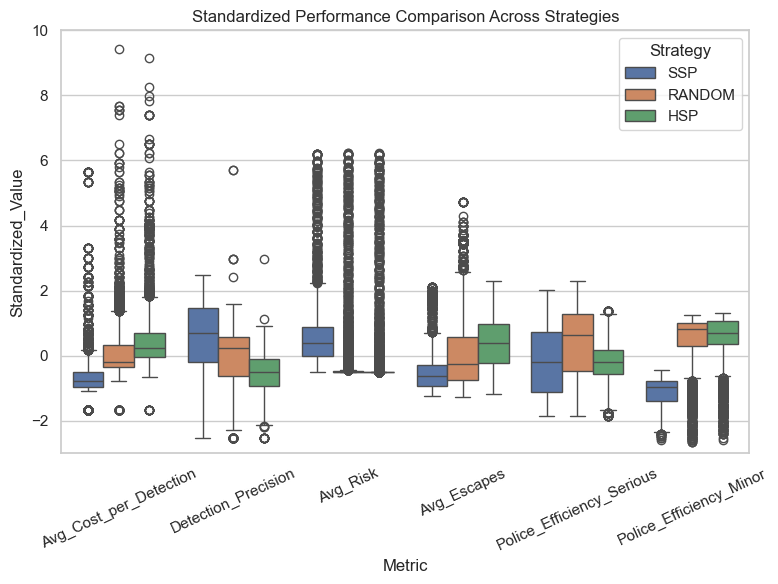

In [113]:
from sklearn.preprocessing import StandardScaler

# 复制数据用于标准化处理
df_norm = df_eff.copy()

# 要标准化的关键指标
selected_metrics = [
    "Avg_Cost_per_Detection",
    "Detection_Precision",
    "Avg_Risk",
    "Avg_Escapes",
    "Police_Efficiency_Serious",
    "Police_Efficiency_Minor"
]

# 对每列指标进行标准化
scaler = StandardScaler()
df_norm[selected_metrics] = scaler.fit_transform(df_norm[selected_metrics])

# 重塑用于绘图
df_plot_norm = df_norm.melt(id_vars="Strategy", value_vars=selected_metrics,
                            var_name="Metric", value_name="Standardized_Value")

# 画标准化箱线图
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_plot_norm, x="Metric", y="Standardized_Value", hue="Strategy")
plt.ylim(-3, 10)
plt.title("Standardized Performance Comparison Across Strategies")
plt.xticks(rotation=25)
plt.tight_layout()
plt.legend(title="Strategy", loc="upper right")
plt.show()


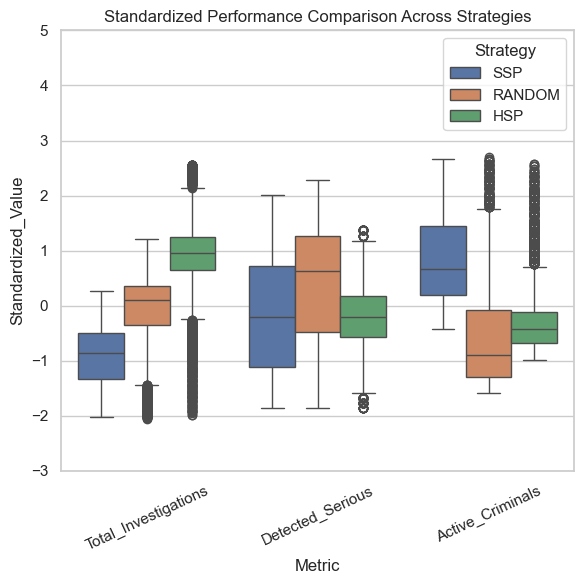

In [104]:
# 复制数据用于标准化处理
df_norm = df_eff.copy()

# 要标准化的关键指标
selected_metrics = [
    "Total_Investigations",
    "Detected_Serious",
    "Active_Criminals"
]

# 对每列指标进行标准化
scaler = StandardScaler()
df_norm[selected_metrics] = scaler.fit_transform(df_norm[selected_metrics])

# 重塑用于绘图
df_plot_norm = df_norm.melt(id_vars="Strategy", value_vars=selected_metrics,
                            var_name="Metric", value_name="Standardized_Value")

# 画标准化箱线图
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_plot_norm, x="Metric", y="Standardized_Value", hue="Strategy")
plt.ylim(-3, 5)
plt.title("Standardized Performance Comparison Across Strategies")
plt.xticks(rotation=25)
plt.tight_layout()
plt.legend(title="Strategy", loc="upper right")
plt.show()

## Regression

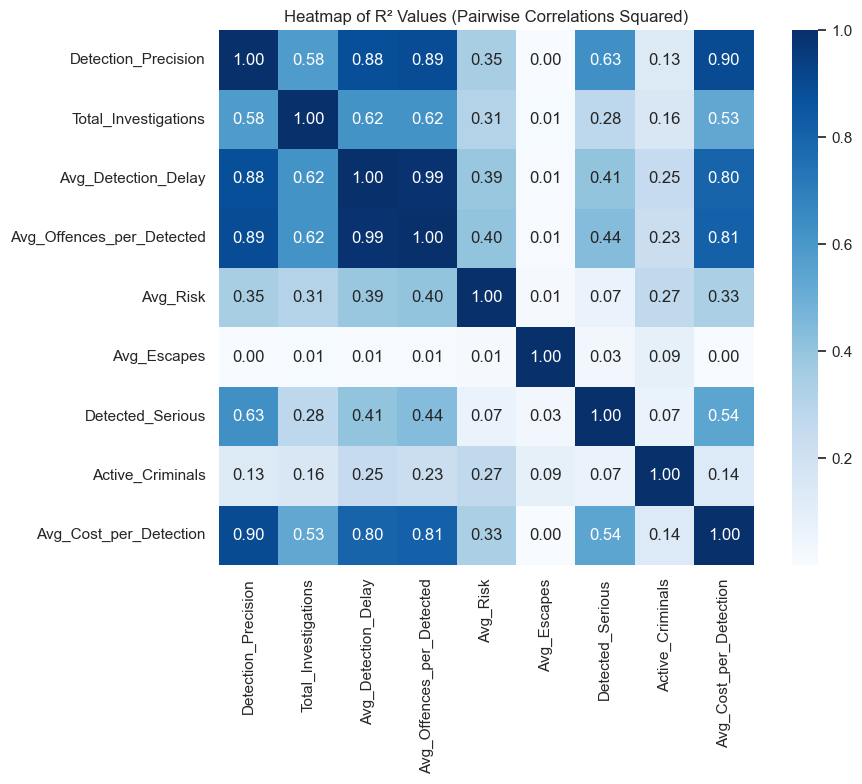

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create correlation matrix (R² as heatmap)
# First build a dataframe with selected variables
selected_df = df_eff[
    [
        "Detection_Precision",
        "Total_Investigations",
        "Avg_Detection_Delay",
        "Avg_Offences_per_Detected",
        "Avg_Risk",
        "Avg_Escapes",
        "Detected_Serious",
        "Active_Criminals",
        "Avg_Cost_per_Detection"
    ]
]

# Compute correlation matrix and square it for R²
corr_matrix = selected_df.corr() ** 2

# Plot as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", square=True)
plt.title("Heatmap of R² Values (Pairwise Correlations Squared)")
plt.tight_layout()
plt.show()


In [114]:
#!pip install statsmodels
import statsmodels.formula.api as smf

# 简单回归：核心变量 + 策略变量
simple_model = smf.ols(
    "Police_Efficiency_Serious ~ Detection_Precision + Total_Investigations + C(Strategy)",
    data=df_eff
).fit()


# 显示结果摘要
simple_model.summary2().tables[1]


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,-0.610939,0.005214,-117.161779,0.000000e+00,-0.621160,-0.600718
C(Strategy)[T.RANDOM],0.321605,0.004700,68.427567,0.000000e+00,0.312392,0.330817
C(Strategy)[T.HSP],-0.079330,0.007545,-10.514068,9.147156e-26,-0.094119,-0.064541
Detection_Precision,3.373013,0.016462,204.893097,0.000000e+00,3.340745,3.405282
Total_Investigations,0.001632,0.000019,85.750812,0.000000e+00,0.001595,0.001669


In [115]:
# 复杂回归：加入更多机制/行为变量
complex_model = smf.ols(
    "Police_Efficiency_Serious ~ Detection_Precision + Total_Investigations + Avg_Risk + Avg_Escapes + Detected_Serious + Avg_Cost_per_Detection + Active_Criminals + C(Strategy)",
    data=df_eff
).fit()


complex_model.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,-6.605827e-15,6.989479e-16,-9.451101e+00,3.839376e-21,-7.975850e-15,-5.235804e-15
C(Strategy)[T.RANDOM],1.293410e-14,1.997469e-16,6.475242e+01,0.000000e+00,1.254257e-14,1.332563e-14
C(Strategy)[T.HSP],4.482525e-15,2.450902e-16,1.828929e+01,6.404602e-74,4.002119e-15,4.962932e-15
Detection_Precision,2.442491e-15,1.096010e-15,2.228530e+00,2.585999e-02,2.941772e-16,4.590804e-15
Total_Investigations,1.883801e-18,9.159701e-19,2.056619e+00,3.974018e-02,8.838795e-20,3.679215e-18
Avg_Risk,-1.221245e-15,1.261976e-15,-9.677249e-01,3.331974e-01,-3.694872e-15,1.252381e-15
Avg_Escapes,-1.526557e-15,1.610685e-16,-9.477688e+00,2.981540e-21,-1.842271e-15,-1.210843e-15
Detected_Serious,5.000000e-02,1.915836e-17,2.609826e+15,0.000000e+00,5.000000e-02,5.000000e-02
Avg_Cost_per_Detection,-3.903128e-18,1.736133e-17,-2.248173e-01,8.221245e-01,-3.793346e-17,3.012721e-17
Active_Criminals,1.040834e-17,9.274282e-18,1.122280e+00,2.617614e-01,-7.770386e-18,2.858707e-17


In [60]:
# Run regression to explain Avg_Cost_per_Detection
cost_model = smf.ols(
    "Avg_Cost_per_Detection ~ C(Strategy) + Detection_Precision + Total_Investigations",
    data=df_eff
).fit()

# Show regression results
cost_model.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,12.740546,0.104501,121.917505,0.000000e+00,12.535710,12.945381
C(Strategy)[T.RANDOM],-1.098310,0.071662,-15.326219,1.279553e-52,-1.238776,-0.957843
C(Strategy)[T.SSP],-3.264154,0.111907,-29.168335,5.654029e-182,-3.483506,-3.044802
Detection_Precision,-13.295255,0.244165,-54.452023,0.000000e+00,-13.773847,-12.816662
Total_Investigations,-0.004828,0.000282,-17.102538,5.864811e-65,-0.005381,-0.004274


## Model Performance

In [158]:
import pandas as pd

# Load the uploaded CSV file
file_path = "/Users/wanghao/Desktop/ssp_abm/data/ssp_results.csv"
df_metrics = pd.read_csv(file_path)

# Show the first few rows to understand the structure
df_metrics.head()


,Strategy,Seed,Step,Total_Investigations,Detection_Precision,Avg_Detection_Delay,Avg_Offences_per_Detected,Avg_Risk,Avg_Escapes,Police_Efficiency,...,Detected_Criminals,Avg_Cost_per_Detection,False_Positives,Active_Serious_Remaining,Total_Serious_Offences,Total_Minor_Offences,Total_Offences,Detections_per_10_Investigations,SSP_Resolved_Serious,Investigation_Success_Rate
0,SSP_Low,0,0,15,0.0,0.0,0.0,0.487856,0.040404,0.00,...,1,0.0,4,7,0,0,0,0.000000,0,0.733333
1,SSP_Low,0,1,29,0.2,3.0,1.6,0.473741,0.063158,0.05,...,5,7.0,7,6,0,1,1,0.344828,0,0.689655
2,SSP_Low,0,2,29,0.2,3.0,1.6,0.460437,0.063158,0.05,...,5,7.0,7,6,0,2,2,0.344828,0,0.689655
3,SSP_Low,0,3,29,0.2,3.0,1.6,0.446301,0.063158,0.05,...,5,7.0,7,6,0,3,3,0.344828,0,0.689655
4,SSP_Low,0,4,29,0.2,3.0,1.6,0.433499,0.063158,0.05,...,5,7.0,7,6,0,4,4,0.344828,0,0.689655


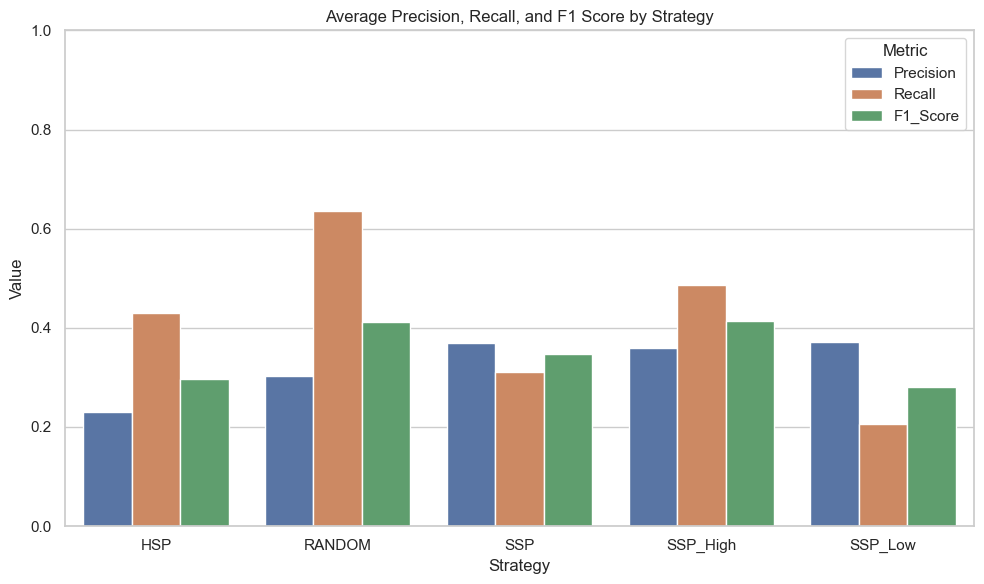

In [159]:
# Recalculate the key metrics (in case the environment was reset)
df_metrics["Precision"] = df_metrics["Detected_Serious"] / df_metrics["Detected_Criminals"]
df_metrics["Recall"] = df_metrics["Detected_Serious"] / (
    df_metrics["Detected_Serious"] + df_metrics["Active_Serious_Remaining"]
)
df_metrics["F1_Score"] = 2 * (df_metrics["Precision"] * df_metrics["Recall"]) / (
    df_metrics["Precision"] + df_metrics["Recall"]
)

# Group by strategy and compute mean of the three metrics
strategy_summary = df_metrics.groupby("Strategy")[["Precision", "Recall", "F1_Score"]].mean().reset_index()

# Plot the average metrics per strategy
import seaborn as sns
import matplotlib.pyplot as plt

# Melt for better plotting
df_melted = strategy_summary.melt(id_vars="Strategy", var_name="Metric", value_name="Value")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Strategy", y="Value", hue="Metric")
plt.title("Average Precision, Recall, and F1 Score by Strategy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [160]:
# Create a styled summary table for the mean precision, recall, and F1 score per strategy
summary_table = df_metrics.groupby("Strategy")[["Precision", "Recall", "F1_Score"]].mean().round(3)

# Display the table to the user
print(summary_table)

          Precision  Recall  F1_Score
Strategy                             
HSP           0.229   0.429     0.297
RANDOM        0.303   0.635     0.411
SSP           0.370   0.310     0.347
SSP_High      0.360   0.486     0.413
SSP_Low       0.372   0.206     0.280


## SSP Sensitive Analysis

In [170]:
from scipy.stats import ttest_rel
import numpy as np
import scipy.stats as stats

# Filter to step=499 and the four target strategies
df_499 = df[(df["Step"] == 499) & (df["Strategy"].isin(["SSP_Low", "SSP_High", "RANDOM", "HSP"]))]

# Pivot for pairing by Seed
pivot_serious = df_499.pivot(index="Seed", columns="Strategy", values="Detected_Serious").dropna()

# Define comparisons
comparisons = [
    ("SSP_Low", "RANDOM"),
    ("SSP_Low", "HSP"),
    ("SSP_High", "RANDOM"),
    ("SSP_High", "HSP"),
]

# Compute stats for each pair
results = []
for a, b in comparisons:
    diff = pivot_serious[a] - pivot_serious[b]
    mean_diff = diff.mean()
    sd_diff = diff.std(ddof=1)
    t_stat, p_val = ttest_rel(pivot_serious[a], pivot_serious[b])
    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=len(diff)-1,
        loc=mean_diff,
        scale=stats.sem(diff)
    )
    significance = (
        "***" if p_val < 0.001 else
        "**" if p_val < 0.01 else
        "*" if p_val < 0.05 else
        ""
    )
    results.append({
        "Comparison": f"{a} vs {b}",
        "Δ Mean": round(mean_diff, 2),
        "SD": round(sd_diff, 2),
        "95% CI": f"[{ci_low:.2f}, {ci_high:.2f}]",
        "t value": round(t_stat, 2),
        "p": f"{p_val:.4f} {significance}"
    })

# Create DataFrame to display
paired_summary_df = pd.DataFrame(results)

percent_changes = []
for a, b in [("SSP_Low", "RANDOM"), ("SSP_Low", "HSP"), ("SSP_High", "RANDOM"), ("SSP_High", "HSP")]:
    change = ((pivot_serious[a] - pivot_serious[b]) / pivot_serious[b]) * 100
    percent_changes.append(change.mean().round(1))


paired_summary_df["% Change"] = [f"{x:+.1f}%" for x in percent_changes]

paired_summary_df[["Comparison", "% Change", "Δ Mean", "SD", "95% CI", "t value", "p"]]

paired_summary_df.set_index("Comparison").T

Comparison,SSP_Low vs RANDOM,SSP_Low vs HSP,SSP_High vs RANDOM,SSP_High vs HSP
Δ Mean,-9.34,6.12,2.8,18.26
SD,6.89,6.12,5.51,6.53
95% CI,"[-11.30, -7.38]","[4.38, 7.86]","[1.23, 4.37]","[16.40, 20.12]"
t value,-9.58,7.07,3.6,19.77
p,0.0000 ***,0.0000 ***,0.0008 ***,0.0000 ***
% Change,-22.8%,+29.4%,+8.2%,+84.2%


In [171]:


# Filter to step=499 and the four target strategies
df_499 = df[(df["Step"] == 499) & (df["Strategy"].isin(["SSP_Low", "SSP_High", "RANDOM", "HSP"]))]

# Pivot for pairing by Seed
pivot_serious = df_499.pivot(index="Seed", columns="Strategy", values="Detected_Criminals").dropna()

# Define comparisons
comparisons = [
    ("SSP_Low", "RANDOM"),
    ("SSP_Low", "HSP"),
    ("SSP_High", "RANDOM"),
    ("SSP_High", "HSP"),
]

# Compute stats for each pair
results = []
for a, b in comparisons:
    diff = pivot_serious[a] - pivot_serious[b]
    mean_diff = diff.mean()
    sd_diff = diff.std(ddof=1)
    t_stat, p_val = ttest_rel(pivot_serious[a], pivot_serious[b])
    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=len(diff)-1,
        loc=mean_diff,
        scale=stats.sem(diff)
    )
    significance = (
        "***" if p_val < 0.001 else
        "**" if p_val < 0.01 else
        "*" if p_val < 0.05 else
        ""
    )
    results.append({
        "Comparison": f"{a} vs {b}",
        "Δ Mean": round(mean_diff, 2),
        "SD": round(sd_diff, 2),
        "95% CI": f"[{ci_low:.2f}, {ci_high:.2f}]",
        "t value": round(t_stat, 2),
        "p": f"{p_val:.4f} {significance}"
    })

# Create DataFrame to display
paired_summary_df = pd.DataFrame(results)

# ((A - B) / B) * 100
# baseline (RANDOM/HSP) 
percent_changes = []
for a, b in [("SSP_Low", "RANDOM"), ("SSP_Low", "HSP"), ("SSP_High", "RANDOM"), ("SSP_High", "HSP")]:
    change = ((pivot_serious[a] - pivot_serious[b]) / pivot_serious[b]) * 100
    percent_changes.append(change.mean().round(1))

paired_summary_df["% Change"] = [f"{x:+.1f}%" for x in percent_changes]

paired_summary_df[["Comparison", "% Change", "Δ Mean", "SD", "95% CI", "t value", "p"]]

paired_summary_df.set_index("Comparison").T

Comparison,SSP_Low vs RANDOM,SSP_Low vs HSP,SSP_High vs RANDOM,SSP_High vs HSP
Δ Mean,-44.72,-27.06,-11.54,6.12
SD,5.68,7.53,5.97,6.86
95% CI,"[-46.33, -43.11]","[-29.20, -24.92]","[-13.24, -9.84]","[4.17, 8.07]"
t value,-55.65,-25.43,-13.68,6.3
p,0.0000 ***,0.0000 ***,0.0000 ***,0.0000 ***
% Change,-46.2%,-33.9%,-11.8%,+8.2%


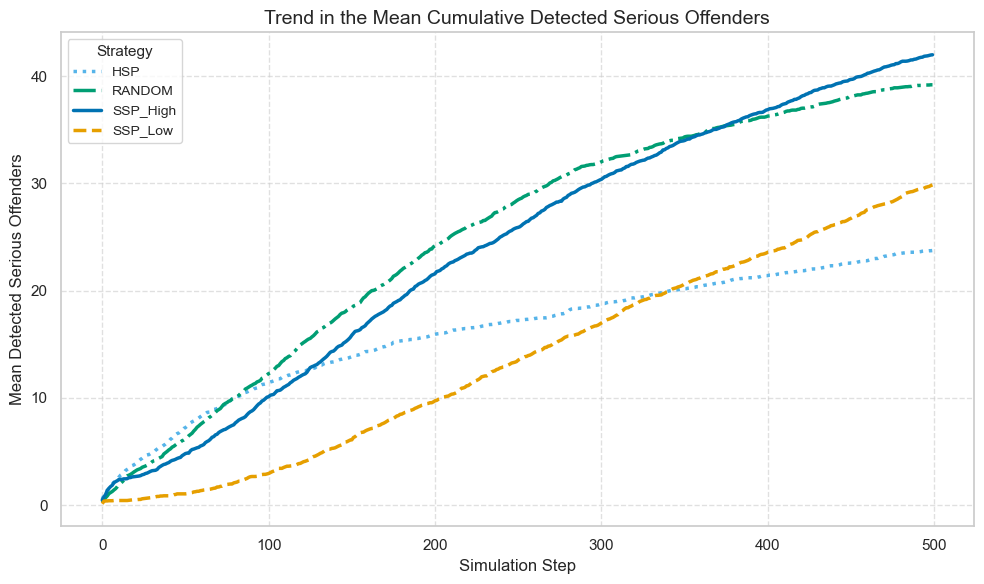

In [173]:

df_trend = df[df["Strategy"].isin(["SSP_Low", "SSP_High", "RANDOM", "HSP"])]

trend_serious = df_trend.groupby(["Step", "Strategy"])["Detected_Serious"].mean().reset_index()


palette_swapped = {
    "SSP_Low": "#E69F00",     
    "SSP_High": "#0072B2",     
    "RANDOM": "#009E73",       
    "HSP": "#56B4E9",          
}

linestyles_swapped = {
    "SSP_Low": "--",       
    "SSP_High": "-",         
    "RANDOM": "-.",
    "HSP": ":"
}

plt.figure(figsize=(10, 6))
for strategy in trend_serious["Strategy"].unique():
    data = trend_serious[trend_serious["Strategy"] == strategy]
    plt.plot(
        data["Step"],
        data["Detected_Serious"],
        label=strategy,
        color=palette_swapped[strategy],
        linestyle=linestyles_swapped[strategy],
        linewidth=2.5
    )

plt.title("Trend in the Mean Cumulative Detected Serious Offenders", fontsize=14)
plt.xlabel("Simulation Step", fontsize=12)
plt.ylabel("Mean Detected Serious Offenders", fontsize=12)
plt.legend(title="Strategy", fontsize=10, title_fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


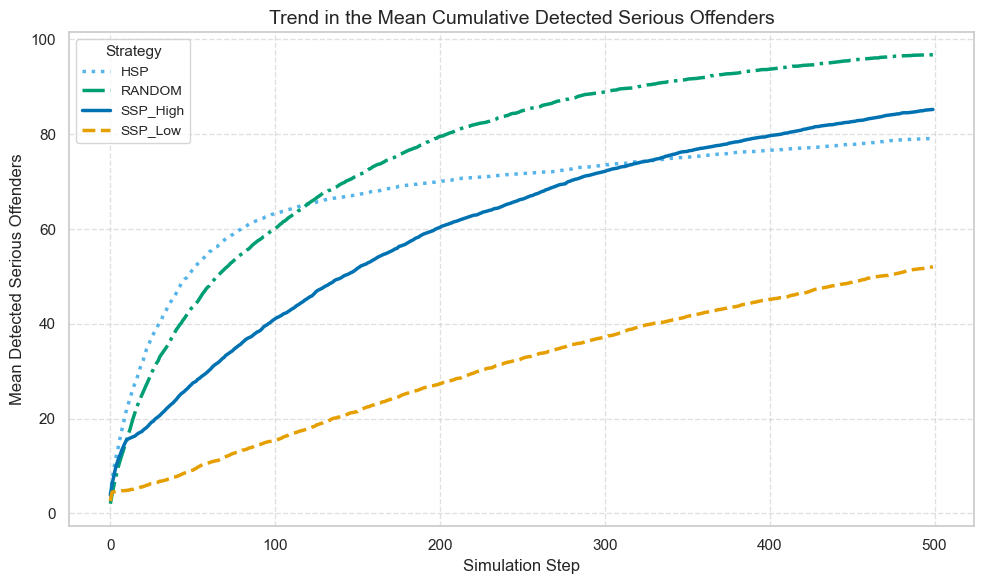

In [175]:

df_trend = df[df["Strategy"].isin(["SSP_Low", "SSP_High", "RANDOM", "HSP"])]

trend_serious = df_trend.groupby(["Step", "Strategy"])["Detected_Criminals"].mean().reset_index()

palette_swapped = {
    "SSP_Low": "#E69F00",     
    "SSP_High": "#0072B2",    
    "RANDOM": "#009E73",       
    "HSP": "#56B4E9",         
}

linestyles_swapped = {
    "SSP_Low": "--",          
    "SSP_High": "-",        
    "RANDOM": "-.",
    "HSP": ":"
}


plt.figure(figsize=(10, 6))
for strategy in trend_serious["Strategy"].unique():
    data = trend_serious[trend_serious["Strategy"] == strategy]
    plt.plot(
        data["Step"],
        data["Detected_Criminals"],
        label=strategy,
        color=palette_swapped[strategy],
        linestyle=linestyles_swapped[strategy],
        linewidth=2.5
    )


plt.title("Trend in the Mean Cumulative Detected Serious Offenders", fontsize=14)
plt.xlabel("Simulation Step", fontsize=12)
plt.ylabel("Mean Detected Serious Offenders", fontsize=12)
plt.legend(title="Strategy", fontsize=10, title_fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
